# All-source interactions: presence, range and parameter compensation

Evaluate four constant-parameter mean-curvature models on the identical five saved folds: linear or literal presence response, with direct fate interactions at one or two hops. Shared mechanical accommodation remains active and can propagate effects beyond the direct radius. We prioritize supported response signs, robustness and identifiability over MSE.

All exclusive identities, including Unassigned, are sources. Linear coefficients use Unassigned as an explicit reference; the presence model fits every source coefficient. Those center/intercept conventions differ, so their numerical values are not intrinsic cell curvatures and should not be compared as such. No weighted-zero column constraints, learned thresholds or N-dependent local parameters are used.

Primary response readouts replace one observed source-B cell with Unassigned while leaving the center and ring populations unchanged. We report intact minus replaced **local preferred residual mean curvature**, before accommodation. These are compositional model contrasts, not removal of a cell or causal interventions. The B→Unassigned replacement can alter both source-presence indicators. Thin lines/points represent folds, which share training data.

This notebook loads saved primary models, evaluates held-out predictions, then performs labeled training-only coefficient refits for accommodation and regularization sensitivity. Diagnostic refits do not replace models or select parameters using outer validation. Pair-specific linear/presence activation maps are supported in code; selection is deferred until these prespecified comparisons reveal whether more flexibility is justified.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import copy
import gc
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import torch
from IPython import get_ipython
from IPython.display import display, Markdown
from src.artifacts.bundle import load_bundle
from src.artifacts.runs import AnalysisRun
from src.artifacts.provenance import workflow_fingerprint
from src.training.coupled_fit import graph_samples
from src.training.energy_fit import TensorEnergyObjective, energy_mse
from scipy.spatial.distance import cdist
from src.analysis.spatial.regions import distance_regions
torch.set_num_threads(4)
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')

## Settings
Choose the completed run and diagnostic support/perturbation rules here. No training dataset settings are overridden. The small reference sample is for response diagnostics only; all held-out cells are used for prediction quality.

In [2]:
# Saved run and execution
TRAINING_RUN = 'training_results/simple_fate_energy_training/all_sources_linear_presence_20260930_153914'  # Four variants across all saved folds.
OUTPUT_TAG = 'all_source_stability'  # Dedicated evaluation folder.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Certified double-precision graph solves.

# Response reference sample and support
SEED = 42  # Curvature-independent reference sampling.
CENTERS_PER_IDENTITY_ORGANOID = 12  # Cap diagnostic contexts per identity per organoid.
MIN_SUPPORT_ORGANOIDS = 20  # Minimum source-present training organoids in every fold.
RESPONSE_FLOOR = .0001  # Avoid interpreting signs of negligible mean contrasts.
REPLACEMENT_IDENTITY = 'Unassigned'  # Replace one existing source; keep ring population fixed.

# Diagnostic refits; never outer-validation selection
PROFILE_FACTORS = np.geomspace(.25, 4., 9)  # Accommodation multipliers; reoptimize all local coefficients.
PROFILE_TOLERANCE = .01  # Relative penalized-objective band; not a confidence interval.
PENALTY_FACTORS = [.1, 1., 10.]  # Conditional linear-penalty multipliers at fitted accommodation.

# Direct anatomical definitions
CRYPT_MAX = .75  # Crypt interior regardless of neck profile.
NECK_MAX = 1.1  # Necks additionally require qualified circumference profiles.

## Load checkpoints and verify fold membership
Verify exact inherited preprocessing membership, primary optimizer convergence, activation, radius and coefficient convention. Models share the same inner organoid holdout. Preserve their original coefficients during all diagnostic refits.

In [3]:
run = AnalysisRun(PROJECT_ROOT/TRAINING_RUN)
if not (run.directory/'complete.json').exists():raise ValueError('Training is incomplete')
source = AnalysisRun(run.settings['source_run'])
membership = json.loads((run.directory/'splits.json').read_text())
if membership!=json.loads((source.directory/'splits.json').read_text()):raise ValueError('Reference fold mismatch')
cohort = load_bundle(run.directory/'cohort')
marker_names = list(cohort['all_marker_names'])
identity_names = marker_names+['Unassigned']
t = len(identity_names)
reference_index = identity_names.index(REPLACEMENT_IDENTITY)
source_indices = list(range(t))
model_names = run.settings['variants']
colors = dict(zip(model_names,['tab:blue','tab:orange','tab:green','tab:red']))
colors['Baseline']='0.5'
OUTPUT_DIR = run.directory/'analysis'/OUTPUT_TAG
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
(OUTPUT_DIR/'predictions').mkdir(exist_ok=True)
config=dict(training_run=str(run.directory),profile_factors=PROFILE_FACTORS.tolist(),penalty_factors=PENALTY_FACTORS,
    profile_tolerance=PROFILE_TOLERANCE,seed=SEED,centers_per_identity_organoid=CENTERS_PER_IDENTITY_ORGANOID,
    min_support_organoids=MIN_SUPPORT_ORGANOIDS,response_floor=RESPONSE_FLOOR,replacement_identity=REPLACEMENT_IDENTITY,
    crypt_max=CRYPT_MAX,neck_max=NECK_MAX,code_sha256=workflow_fingerprint(PROJECT_ROOT/'legacy/energy_models/notebooks/benchmarks/simple_fate_energy_evaluation.ipynb'))
(OUTPUT_DIR/'settings.json').write_text(json.dumps(config,indent=2))
models={};fit_info={};training_audit=[]
for split in membership:
    fold=split['fold'];inner=[]
    for name in model_names:
        record=run.records[(run.records.name==name)&(run.records.fold==fold)]
        if len(record)!=1:raise ValueError('Missing or duplicate model')
        record=record.iloc[0];payload=load_bundle(run.directory/record.bundle)
        m=payload['model'];info=payload['metrics'];activation,radius=name.split('_r')
        if m.activation!=activation or m.radius!=int(radius) or m.center_response or m.size_dependent:raise ValueError('Model specification differs')
        if not m.pairs or not m.accommodation or m.pair_constraints!='direct' or m.source_indices!=source_indices:raise ValueError('Wrong interaction setup')
        if m.reference_source!=(reference_index if activation=='linear' else None):raise ValueError('Wrong source reference')
        if info['fit_organoids']!=split['train'] or not info['optimizer']['success']:raise ValueError('Invalid fitted checkpoint')
        history=json.loads((run.directory/'history'/f'{record.key}.json').read_text())
        training_audit.append(dict(name=name,fold=fold,trials=len(history),failed_trials=sum(not row['success'] for row in history),fit_seconds=info['fit_seconds']))
        models[name,fold]=m;fit_info[name,fold]=info
        inner.append((info['inner_train'],info['inner_validation']))
    if any(x!=inner[0] for x in inner):raise ValueError('Different inner folds')
(OUTPUT_DIR/'training_audit.json').write_text(json.dumps(training_audit,indent=2))
print('Loaded',len(models),'models; identities:',identity_names)

Loaded 20 models; identities: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin', 'Unassigned']


## Held-out predictions, spatial differences and neighborhood novelty
All MSEs average within each organoid and then across organoids. Regions come directly from graph/mesh annotations. Edge-difference MSE compares predicted and measured curvature differences on unique adjacency edges; it uses targets only for scoring. Neighborhood novelty is the mean distance of a validation organoid's fate-composition features to its closest training organoid. This is a diagnostic of ordinary folds, not a new composition-blocked training experiment.

In [4]:
scores = []
spatial_rows=[]
novelty_rows=[]
ring_audit=[]
reference_rows = []
reference_counts = []
zero_rows = []
region_tables = []
rng = np.random.default_rng(SEED)
audit = []
for split in membership:
    fold = split['fold']
    inputs = load_bundle(run.directory/f'inputs/fold_{fold}_mean')
    graphs = inputs['groups']['val']
    if [g.organoid_str for g in graphs]!=split['validation']:raise ValueError('Validation ordering differs')
    samples = graph_samples(graphs,2)
    train_samples=graph_samples(inputs['groups']['train'],2)
    def composition_signature(sample):
        counts=sample['counts'];pop=counts.sum(2,keepdims=True)
        f=np.divide(counts,pop,out=np.zeros_like(counts,dtype=float),where=pop>0)
        by_center=np.zeros((t,2,t))
        for a in range(t):
            take=sample['identity']==a
            if take.any():by_center[a]=f[take].mean(0)
        return np.r_[np.bincount(sample['identity'],minlength=t)/len(sample['identity']),by_center.ravel()]
    train_composition=np.stack([composition_signature(s) for s in train_samples])
    val_composition=np.stack([composition_signature(s) for s in samples])
    distances=cdist(val_composition,train_composition).min(1)
    novelty_rows.extend(dict(fold=fold,organoid_str=s['organoid_str'],novelty=float(d)) for s,d in zip(samples,distances))
    for role,group in [('train',train_samples),('validation',samples)]:
        ring_audit.append(dict(fold=fold,role=role,empty_hop1=sum(int((s['counts'][:,0].sum(1)==0).sum()) for s in group),
            empty_hop2=sum(int((s['counts'][:,1].sum(1)==0).sum()) for s in group)))
    del train_samples
    annotations = {}
    for g,s in zip(graphs,samples):
        raw = copy.deepcopy(cohort['raw_graphs'][g.organoid_str]);raw.x=g.x.clone()
        regions = distance_regions(raw,PROJECT_ROOT/'training_data'/run.settings['dataset'],marker_names=marker_names,
            crypt_marker='LGR5',crypt_max=CRYPT_MAX,neck_max=NECK_MAX)
        annotations[g.organoid_str] = regions.region.to_numpy();region_tables.append(regions)
        no_sources = s['counts'][:,:,source_indices].sum((1,2))==0
        for a in np.unique(s['identity']):
            eligible = np.flatnonzero(s['identity']==a)
            zero_rows.append(dict(organoid_str=g.organoid_str,center=identity_names[a],cells=len(eligible),
                source_free_cells=int(no_sources[eligible].sum()),source_free_fraction=float(no_sources[eligible].mean())))
            selected = np.sort(rng.choice(eligible,min(len(eligible),CENTERS_PER_IDENTITY_ORGANOID),replace=False))
            reference_counts.append(s['counts'][selected])
            reference_rows.extend(dict(organoid_str=g.organoid_str,node=int(i),identity=int(a),N=s['N']) for i in selected)
    features = [{k:v for k,v in s.items() if k!='y'} for s in samples]
    predictions = {name:models[name,fold].predict_samples(features,device=DEVICE) for name in model_names}
    predictions['Baseline'] = [np.zeros(len(g.x)) for g in graphs]
    for name in model_names:
        m = models[name,fold]
        s=features[0]
        difference = float(np.max(abs(m.predict_sample(s,N=80,device=DEVICE)-m.predict_sample(s,N=700,device=DEVICE))))
        if difference>1e-12:raise ValueError('Residual model depends on supplied N')
        audit.append(dict(name=name,fold=fold,N_sweep_max_difference=difference))
    offsets = np.r_[0,np.cumsum([len(g.x) for g in graphs])]
    for name,arrays in predictions.items():
        truths=[];preds=[]
        for g,pred in zip(graphs,arrays):
            residual=g.y.numpy().reshape(-1);error=(pred-residual)**2;labels=annotations[g.organoid_str]
            edges=g.edge_index.numpy();edges=np.unique(np.sort(edges,axis=0),axis=1);edges=edges[:,edges[0]!=edges[1]]
            truth_diff=residual[edges[0]]-residual[edges[1]];pred_diff=pred[edges[0]]-pred[edges[1]]
            spatial_rows.append(dict(name=name,fold=fold,organoid_str=g.organoid_str,
                edge_mse=float(np.mean((pred_diff-truth_diff)**2)),true_edge_energy=float(np.mean(truth_diff**2)),predicted_edge_energy=float(np.mean(pred_diff**2))))
            if not np.isfinite(pred).all():raise ValueError('Nonfinite predictions')
            reconstructed=0.
            for label in ['total',*np.unique(labels)]:
                take=np.ones(len(error),bool) if label=='total' else labels==label
                mse=float(error[take].mean())
                scores.append(dict(name=name,fold=fold,organoid_str=g.organoid_str,N=len(g.x),region=label,mse=mse))
                if label!='total':reconstructed+=mse*take.mean()
            if not np.isclose(reconstructed,error.mean(),rtol=1e-10,atol=1e-12):raise ValueError('Regional reconstruction mismatch')
            baseline=np.asarray(inputs['baseline_offsets'][g.organoid_str]).reshape(-1)
            truths.append(residual+baseline);preds.append(pred+baseline)
        np.savez_compressed(OUTPUT_DIR/'predictions'/f'{name}_f{fold}.npz',prediction=np.concatenate(preds),truth=np.concatenate(truths),
            offsets=offsets,organoid_ids=np.asarray(split['validation']))
    print('Evaluated fold',fold,flush=True)
scores=pd.DataFrame(scores);scores.to_csv(OUTPUT_DIR/'validation_mse.csv',index=False)
pd.concat(region_tables,ignore_index=True).to_csv(OUTPUT_DIR/'regions.csv.gz',index=False)
reference=pd.DataFrame(reference_rows);counts=np.concatenate(reference_counts)
reference.to_csv(OUTPUT_DIR/'reference_centers.csv.gz',index=False)
np.savez_compressed(OUTPUT_DIR/'reference_features.npz',counts=counts,identity=reference.identity.to_numpy())
zero_support=pd.DataFrame(zero_rows);zero_support.to_csv(OUTPUT_DIR/'source_free_organoids.csv',index=False)
summary=scores.groupby(['name','region']).mse.agg(['mean','sem','count']).reset_index()
summary.to_csv(OUTPUT_DIR/'mse_summary.csv',index=False)
saved=pd.read_csv(run.directory/'validation_mse.csv').set_index(['name','fold','organoid_str']).mse
restored=scores[scores.region=='total'].query('name != "Baseline"').set_index(['name','fold','organoid_str']).mse
if set(saved.index)!=set(restored.index):raise ValueError('Saved score membership differs')
max_difference=float((saved-restored).abs().max())
if max_difference>1e-10:raise ValueError('Restored scores changed')
(OUTPUT_DIR/'prediction_audit.json').write_text(json.dumps(dict(saved_score_max_difference=max_difference,N_invariance=audit),indent=2))

spatial=pd.DataFrame(spatial_rows);spatial.to_csv(OUTPUT_DIR/'spatial_scores.csv',index=False)
novelty=pd.DataFrame(novelty_rows);novelty.to_csv(OUTPUT_DIR/'neighborhood_novelty.csv',index=False)
pd.DataFrame(ring_audit).to_csv(OUTPUT_DIR/'ring_population_audit.csv',index=False)
if any(r['empty_hop1'] or r['empty_hop2'] for r in ring_audit):
    print('WARNING: empty rings break the exhaustive-fraction reference equivalence; inspect ring_population_audit.csv.')

/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:121: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


Evaluated fold 0


Evaluated fold 1


Evaluated fold 2


Evaluated fold 3


Evaluated fold 4


## Prediction quality by radius, region and fate-context novelty
Use saved FiLM and prior simple models only for compact total-MSE context. Regional plots and spatial scores focus on the four new models. Novelty bands are defined separately within each validation fold, without using curvature; sparse or rare identities can contribute to novelty.

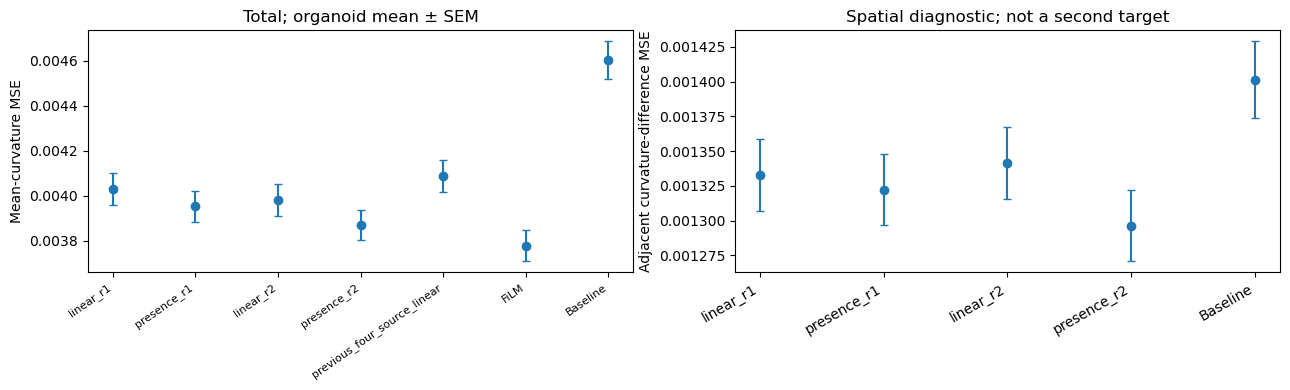

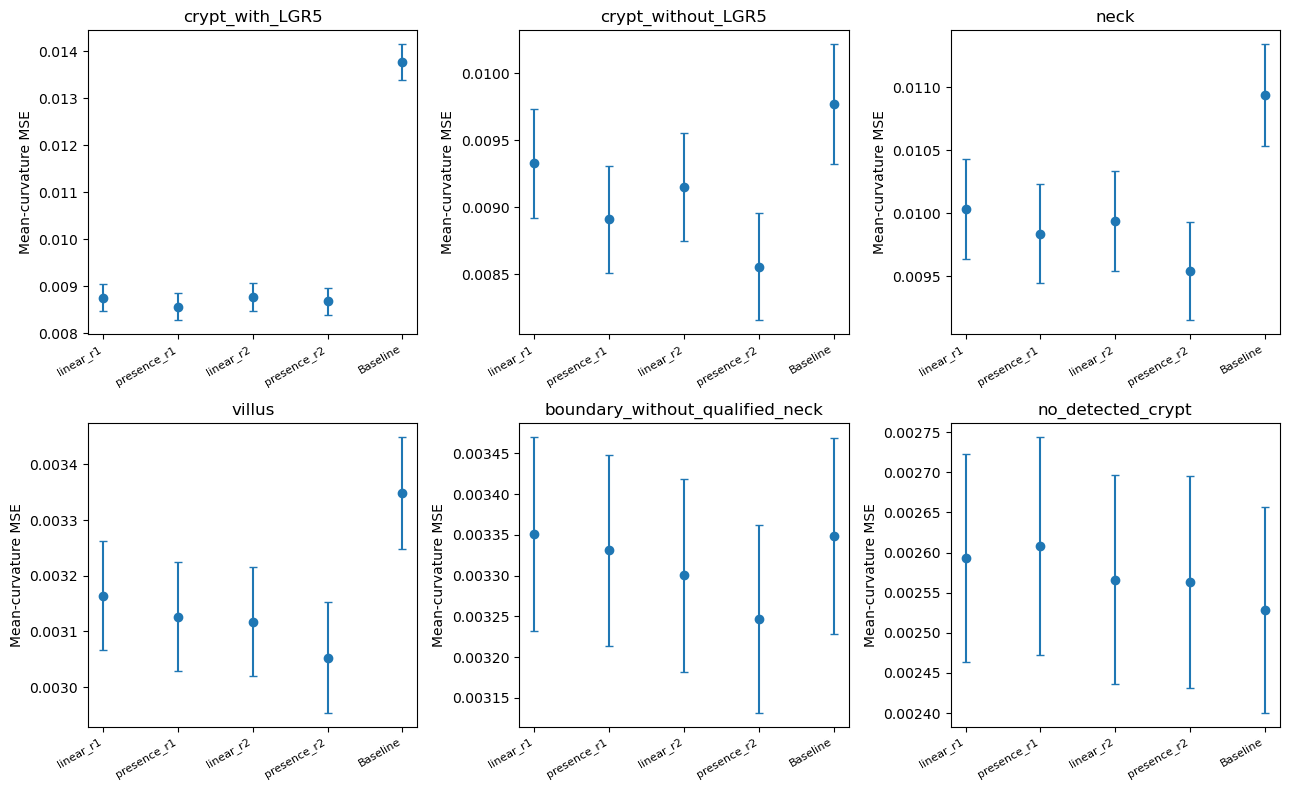

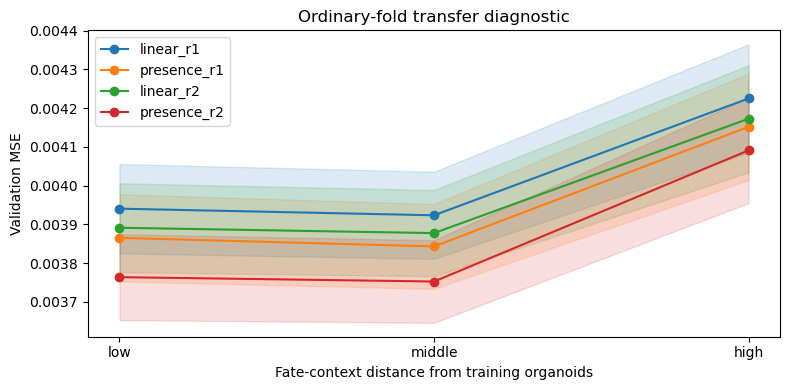

In [5]:
total=scores[scores.region=='total'].copy()
comparison=[total[['name','fold','organoid_str','mse']]]
for directory,label,saved_name in [
    (source.directory,'FiLM','FiLM'),
    (PROJECT_ROOT/'training_results/simple_fate_energy_training/constant_secretory_sources_20260930_144417','previous_four_source_linear','linear')]:
    d=pd.read_csv(directory/'validation_mse.csv');d=d[d.name==saved_name].copy();d['name']=label
    expected=set(map(tuple,total[['fold','organoid_str']].drop_duplicates().to_numpy()))
    if set(map(tuple,d[['fold','organoid_str']].to_numpy()))!=expected:raise ValueError('Reference validation differs')
    comparison.append(d[['name','fold','organoid_str','mse']])
accuracy=pd.concat(comparison).groupby('name').mse.agg(['mean','sem','count'])
accuracy.to_csv(OUTPUT_DIR/'accuracy.csv')
fig,axes=plt.subplots(1,2,figsize=(13,4))
order=model_names+['previous_four_source_linear','FiLM','Baseline'];d=accuracy.reindex(order);x=np.arange(len(d))
axes[0].errorbar(x,d['mean'],yerr=d['sem'],fmt='o',capsize=3);axes[0].set_xticks(x,d.index,rotation=35,ha='right',fontsize=8)
axes[0].set(ylabel='Mean-curvature MSE',title='Total; organoid mean ± SEM')
d=spatial.groupby('name').edge_mse.agg(['mean','sem']).reindex(model_names+['Baseline']);x=np.arange(len(d))
axes[1].errorbar(x,d['mean'],yerr=d['sem'],fmt='o',capsize=3);axes[1].set_xticks(x,d.index,rotation=30,ha='right')
axes[1].set(ylabel='Adjacent curvature-difference MSE',title='Spatial diagnostic; not a second target')
fig.tight_layout();fig.savefig(OUTPUT_DIR/'accuracy_spatial.png',dpi=160);plt.show()
labels=['crypt_with_LGR5','crypt_without_LGR5','neck','villus','boundary_without_qualified_neck','no_detected_crypt']
fig,axes=plt.subplots(2,3,figsize=(13,8))
for ax,label in zip(axes.flat,labels):
    d=summary[summary.region==label].set_index('name').reindex(model_names+['Baseline']);x=np.arange(len(d))
    ax.errorbar(x,d['mean'],yerr=d['sem'],fmt='o',capsize=3);ax.set_xticks(x,d.index,rotation=30,ha='right',fontsize=8)
    ax.set(title=label,ylabel='Mean-curvature MSE')
fig.tight_layout();fig.savefig(OUTPUT_DIR/'regional_accuracy.png',dpi=160);plt.show()
novelty['novelty_band']=novelty.groupby('fold').novelty.transform(lambda x:pd.qcut(x.rank(method='first'),3,labels=['low','middle','high']).astype(str))
novel_scores=total.merge(novelty,on=['fold','organoid_str'],validate='many_to_one')
novel_summary=novel_scores.groupby(['name','novelty_band']).mse.agg(['mean','sem','count']).reset_index()
novel_summary.to_csv(OUTPUT_DIR/'novelty_mse.csv',index=False)
fig,ax=plt.subplots(figsize=(8,4))
for name in model_names:
    d=novel_summary[novel_summary.name==name].set_index('novelty_band').reindex(['low','middle','high']);x=np.arange(3)
    ax.plot(x,d['mean'],'o-',label=name,color=colors[name]);ax.fill_between(x,d['mean']-d['sem'],d['mean']+d['sem'],alpha=.15,color=colors[name])
ax.set_xticks(x,['low','middle','high']);ax.set(xlabel='Fate-context distance from training organoids',ylabel='Validation MSE',title='Ordinary-fold transfer diagnostic');ax.legend()
fig.tight_layout();fig.savefig(OUTPUT_DIR/'novelty_accuracy.png',dpi=160);plt.show()

## Supported replacements and fold agreement
For each center identity and non-reference source, select observed contexts containing that source at the indicated hop. Replace one source cell with Unassigned in the same ring, keeping all other fractions fixed. Report intact minus replaced local preference, with equal organoid weight. Presence may remain unchanged when other source cells remain; adding the first Unassigned cell can also contribute. Only contexts with adequate training support in every fold enter stability summaries. The same pooled reference contexts are evaluated with every fold model; these are descriptive model readouts, not held-out accuracy estimates.

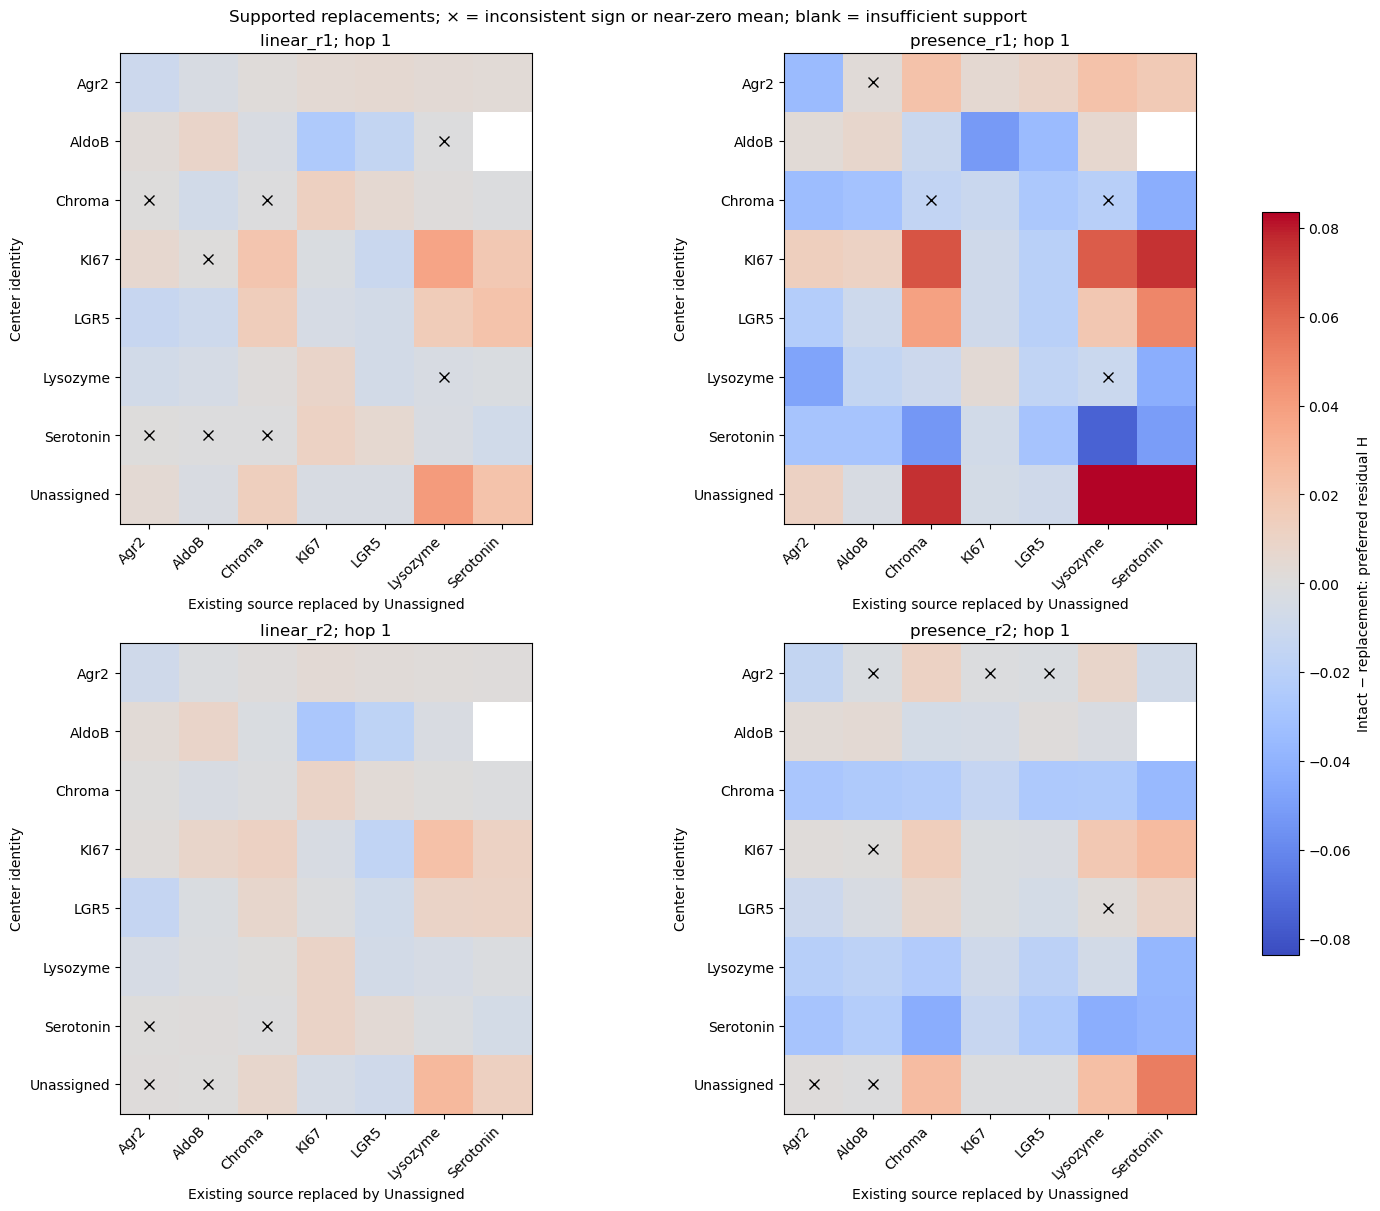

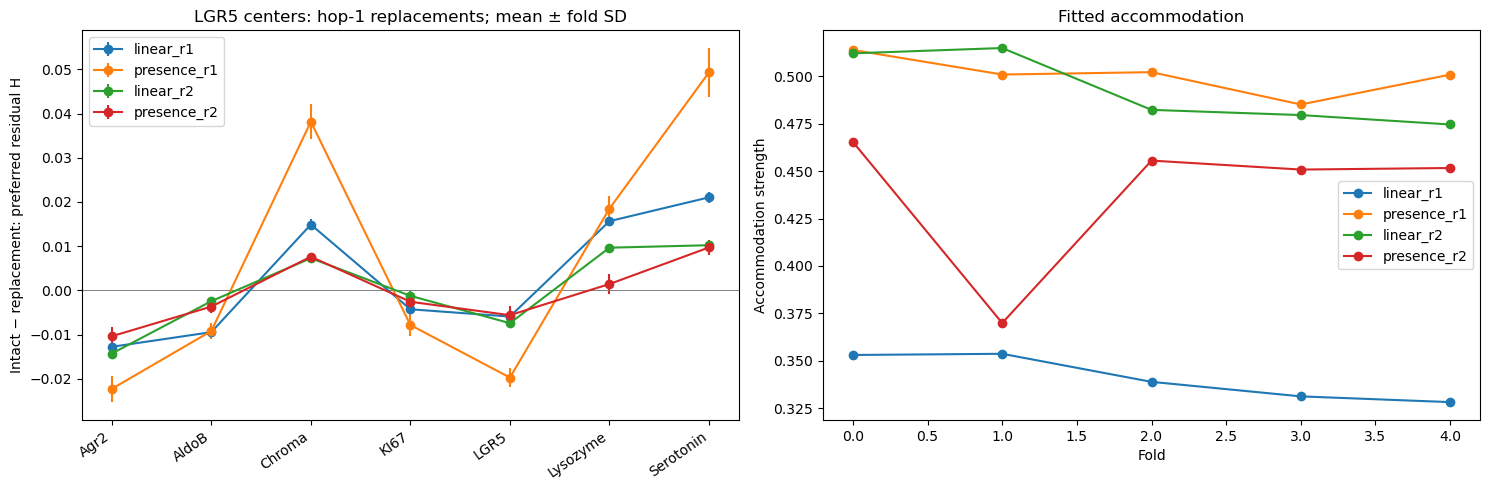

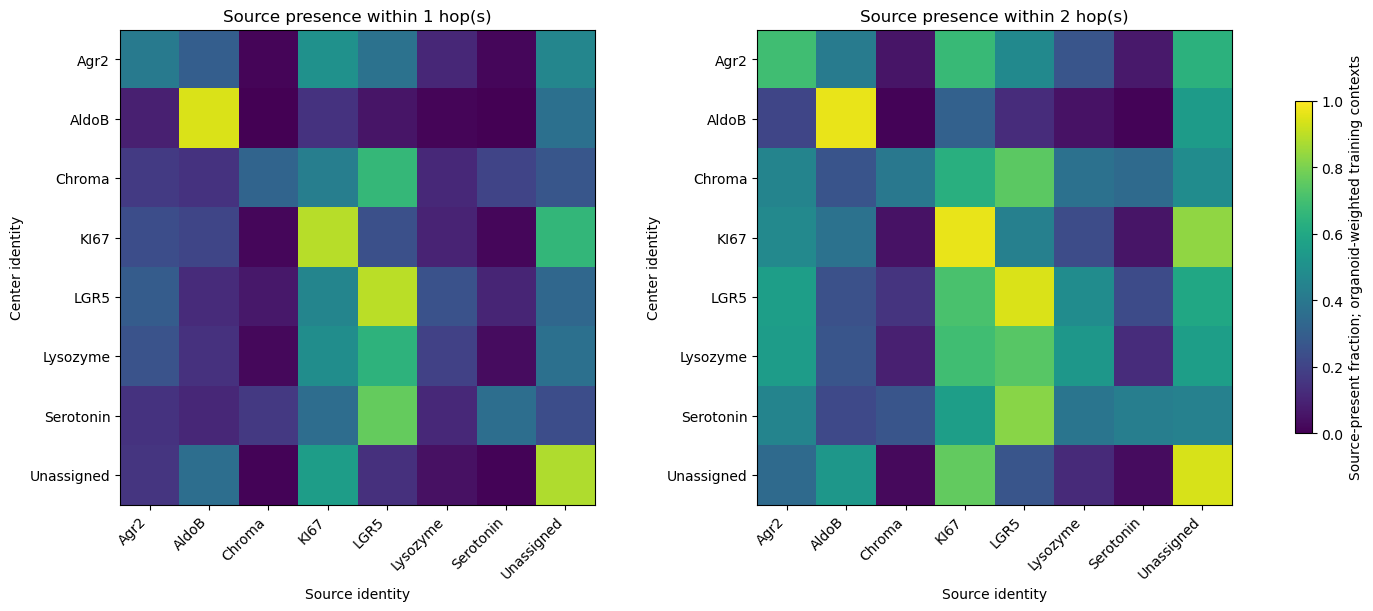

In [5]:
replacement_designs={};support_rows=[];response_rows=[];coefficient_rows=[];accommodation_rows=[]
identity=reference.identity.to_numpy();orgs=reference.organoid_str.to_numpy()
train_masks={s['fold']:reference.organoid_str.isin(s['train']).to_numpy() for s in membership}
# Build a mean design difference once per model specification, with equal organoid weights.
for name in model_names:
    first=models[name,membership[0]['fold']]
    contexts=[];columns=[]
    for hop in range(1,first.radius+1):
        for a,A in enumerate(identity_names):
            for b,B in enumerate(identity_names):
                if b==reference_index:continue
                take=(identity==a)&(counts[:,hop-1,b]>0)
                support_by_fold=[len(np.unique(orgs[take&train_masks[s['fold']]])) for s in membership]
                supported=min(support_by_fold)>=MIN_SUPPORT_ORGANOIDS
                support_rows.append(dict(name=name,hop=hop,center=A,source=B,organoids=len(np.unique(orgs[take])),min_training_organoids=min(support_by_fold),supported=supported,
                    last_source_fraction=float((counts[take,:first.radius,b].sum(1)==1).mean()) if take.any() else np.nan))
                if not supported:continue
                original=dict(identity=identity[take],counts=counts[take].copy(),N=1.)
                changed=copy.deepcopy(original);changed['counts'][:,hop-1,b]-=1;changed['counts'][:,hop-1,reference_index]+=1
                delta=first.design(original)-first.design(changed)
                selected_orgs=orgs[take];unique_orgs,inverse,number=np.unique(selected_orgs,return_inverse=True,return_counts=True)
                weights=1/(len(unique_orgs)*number[inverse])
                columns.append(weights@delta);contexts.append(dict(hop=hop,center=A,source=B))
    replacement_designs[name]=(pd.DataFrame(contexts),np.stack(columns))
    for split in membership:
        fold=split['fold'];m=models[name,fold];co=m.coefficients([1]);physical=m.array(m.weights)*float(m.target_scale)
        meta,design=replacement_designs[name]
        response_rows.extend(dict(name=name,fold=fold,**row,response=float(v)) for row,v in zip(meta.to_dict('records'),design@physical))
        for a,A in enumerate(identity_names):
            coefficient_rows.append(dict(name=name,fold=fold,parameter=f'a:{A}',value=float(co['center'][0,a])))
            for b,B in enumerate(identity_names):coefficient_rows.append(dict(name=name,fold=fold,parameter=f'beta:{A}<-{B}',value=float(co['amplitude'][0,a,b])))
        accommodation_rows.append(dict(name=name,fold=fold,strength=float(m.strength([1])[0])))
support=pd.DataFrame(support_rows);responses=pd.DataFrame(response_rows);coefficients=pd.DataFrame(coefficient_rows);accommodation=pd.DataFrame(accommodation_rows)
for filename,frame in [('replacement_support',support),('replacement_responses',responses),('coefficients',coefficients),('accommodation',accommodation)]:frame.to_csv(OUTPUT_DIR/f'{filename}.csv',index=False)
stability=responses.groupby(['name','hop','center','source']).response.agg(['mean','std','min','max']).reset_index()
stability['relative_dispersion']=stability['std']/stability['mean'].abs().clip(lower=RESPONSE_FLOOR)
stability['unanimous_sign']=(stability['min']>0)|(stability['max']<0)
stability['near_zero']=abs(stability['mean'])<RESPONSE_FLOOR
stability.to_csv(OUTPUT_DIR/'replacement_stability.csv',index=False)
fig,axes=plt.subplots(2,2,figsize=(15,12),layout="constrained")
limit=max(abs(responses[responses.hop==1].response).quantile(.99),RESPONSE_FLOOR)
for ax,name in zip(axes.flat,model_names):
    d=stability[(stability.name==name)&(stability.hop==1)]
    table=d.pivot(index='center',columns='source',values='mean').reindex(index=identity_names,columns=[x for x in identity_names if x!=REPLACEMENT_IDENTITY])
    mesh=ax.imshow(table,cmap='coolwarm',norm=TwoSlopeNorm(vmin=-limit,vcenter=0,vmax=limit))
    for _,row in d.iterrows():
        if not row.unanimous_sign or row.near_zero:ax.plot(list(table.columns).index(row.source),identity_names.index(row.center),'kx',ms=7)
    ax.set_xticks(range(len(table.columns)),table.columns,rotation=45,ha='right');ax.set_yticks(range(t),identity_names)
    ax.set(title=name+'; hop 1',xlabel='Existing source replaced by Unassigned',ylabel='Center identity')
fig.colorbar(mesh,ax=axes.ravel().tolist(),shrink=.7,label='Intact − replacement: preferred residual H')
fig.suptitle('Supported replacements; × = inconsistent sign or near-zero mean; blank = insufficient support')
fig.savefig(OUTPUT_DIR/'replacement_heatmaps.png',dpi=160,bbox_inches='tight');plt.show()
fig,axes=plt.subplots(1,2,figsize=(15,5))
for name in model_names:
    d=responses[(responses.name==name)&(responses.center=='LGR5')&(responses.hop==1)]
    agg=d.groupby('source').response.agg(['mean','std']).reindex([x for x in identity_names if x!=REPLACEMENT_IDENTITY]);x=np.arange(len(agg))
    axes[0].errorbar(x,agg['mean'],yerr=agg['std'],fmt='o-',label=name,color=colors[name])
    a=accommodation[accommodation.name==name];axes[1].plot(a.fold,a.strength,'o-',label=name,color=colors[name])
axes[0].set_xticks(x,agg.index,rotation=35,ha='right');axes[0].axhline(0,color='0.5',lw=.7);axes[0].set(title='LGR5 centers: hop-1 replacements; mean ± fold SD',ylabel='Intact − replacement: preferred residual H');axes[0].legend()
axes[1].set(xlabel='Fold',ylabel='Accommodation strength',title='Fitted accommodation');axes[1].legend()
fig.tight_layout();fig.savefig(OUTPUT_DIR/'lgr5_and_accommodation.png',dpi=160);plt.show()
# Presence identifiability requires observing both states, not just positive-source support.
presence_rows=[]
for radius in [1,2]:
    present=counts[:,:radius].sum(1)>0
    for a,A in enumerate(identity_names):
        for b,B in enumerate(identity_names):
            for split in membership:
                fold=split['fold'];take=(identity==a)&train_masks[fold]
                selected_orgs=orgs[take];value=present[take,b]
                organoid_means=pd.DataFrame(dict(organoid=selected_orgs,present=value)).groupby('organoid').present.mean()
                presence_rows.append(dict(radius=radius,fold=fold,center=A,source=B,
                    present_organoids=len(np.unique(selected_orgs[value])),absent_organoids=len(np.unique(selected_orgs[~value])),
                    fraction_present=float(organoid_means.mean())))
presence_support=pd.DataFrame(presence_rows);presence_support.to_csv(OUTPUT_DIR/'presence_variation_support.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(14,6),layout='constrained')
for ax,radius in zip(axes,[1,2]):
    tab=presence_support[presence_support.radius==radius].groupby(['center','source']).fraction_present.mean().unstack().reindex(index=identity_names,columns=identity_names)
    im=ax.imshow(tab,vmin=0,vmax=1,cmap='viridis');ax.set_xticks(range(t),identity_names,rotation=45,ha='right');ax.set_yticks(range(t),identity_names)
    ax.set(title=f'Source presence within {radius} hop(s)',xlabel='Source identity',ylabel='Center identity')
fig.colorbar(im,ax=axes.tolist(),shrink=.7,label='Source-present fraction; organoid-weighted training contexts')
fig.savefig(OUTPUT_DIR/'presence_support.png',dpi=160,bbox_inches='tight');plt.show()


## Accommodation profiles and regularization sensitivity
At each fixed accommodation multiplier refit all local coefficients on outer training data. Keep the saved shrinkage and compare penalized objective, validation error and the same replacement contrasts. Separately vary center/pair shrinkage together at fitted accommodation. Sensitivity bands are descriptive, not confidence intervals. Design rank is checked before ridge; inverse-Gram correlations are summarized only for full-rank designs. Absolute coefficient comparisons across linear/presence reference conventions are inappropriate.

Profiled linear_r1 fold 0 design rank 64 / 64


Profiled presence_r1 fold 0 design rank 72 / 72


Profiled linear_r2 fold 0 design rank 64 / 64


Profiled presence_r2 fold 0 design rank 72 / 72


Profiled linear_r1 fold 1 design rank 64 / 64


...

Profiled presence_r2 fold 3 design rank 72 / 72


Profiled linear_r1 fold 4 design rank 64 / 64


Profiled presence_r1 fold 4 design rank 72 / 72


Profiled linear_r2 fold 4 design rank 64 / 64


Profiled presence_r2 fold 4 design rank 72 / 72


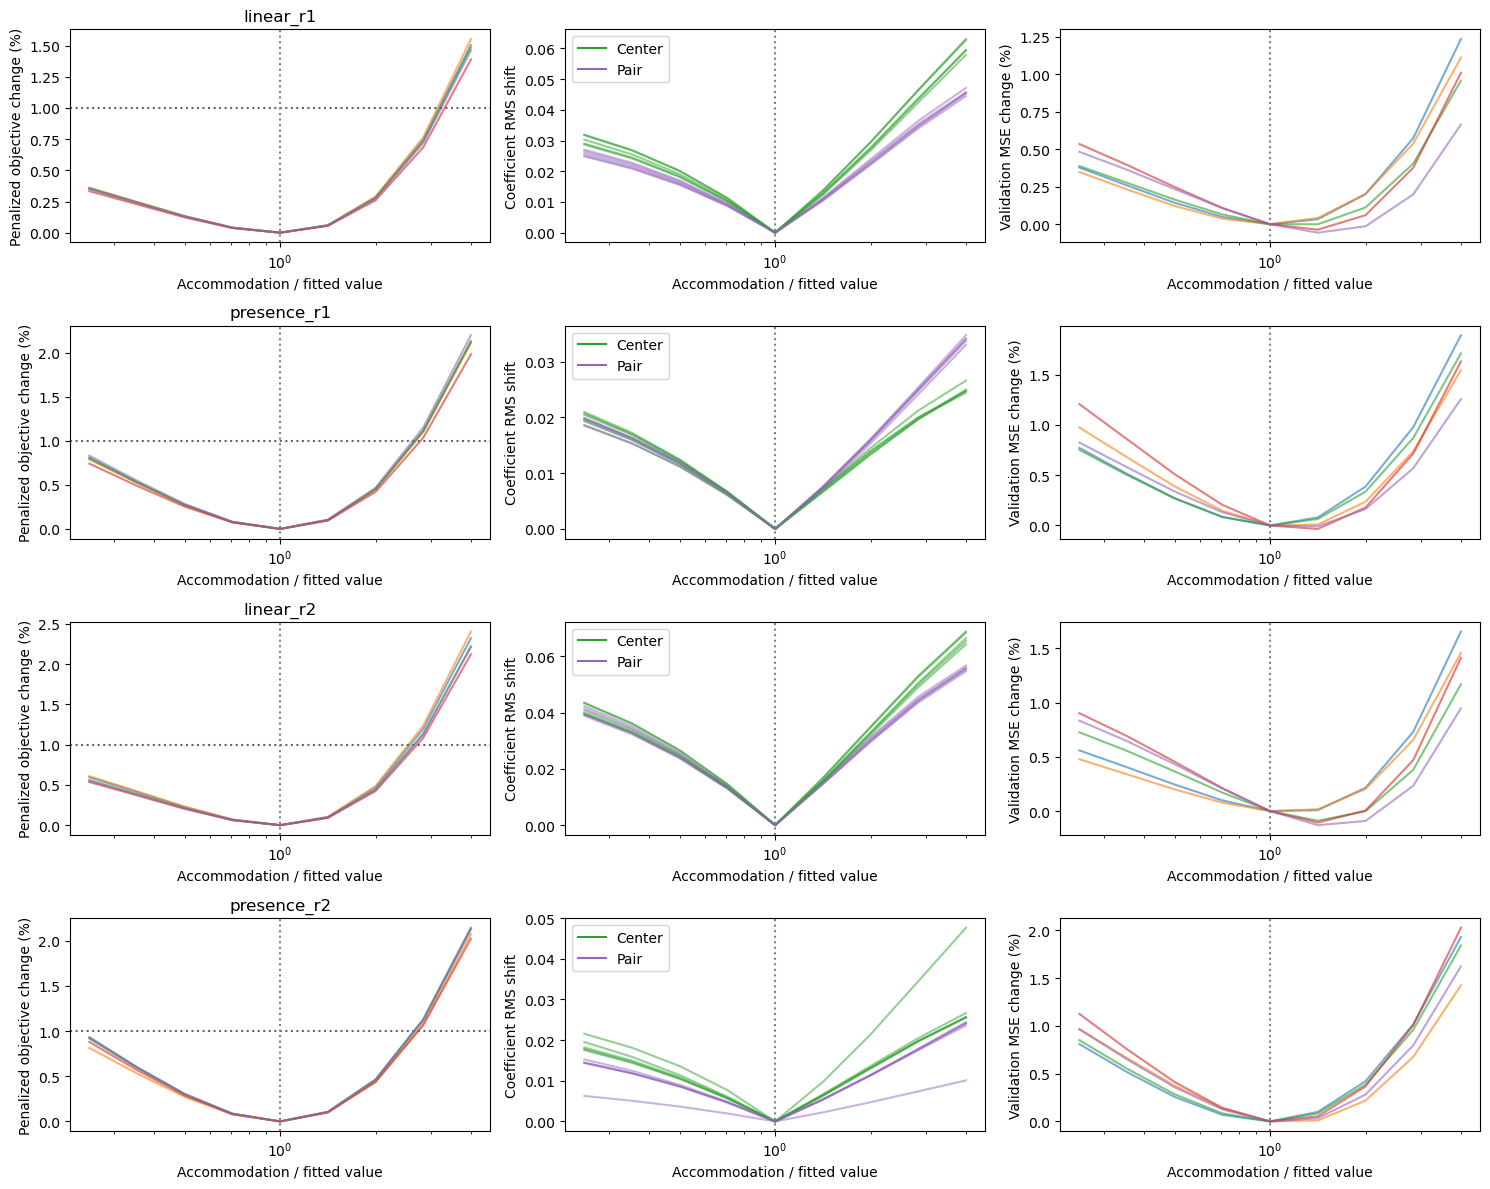

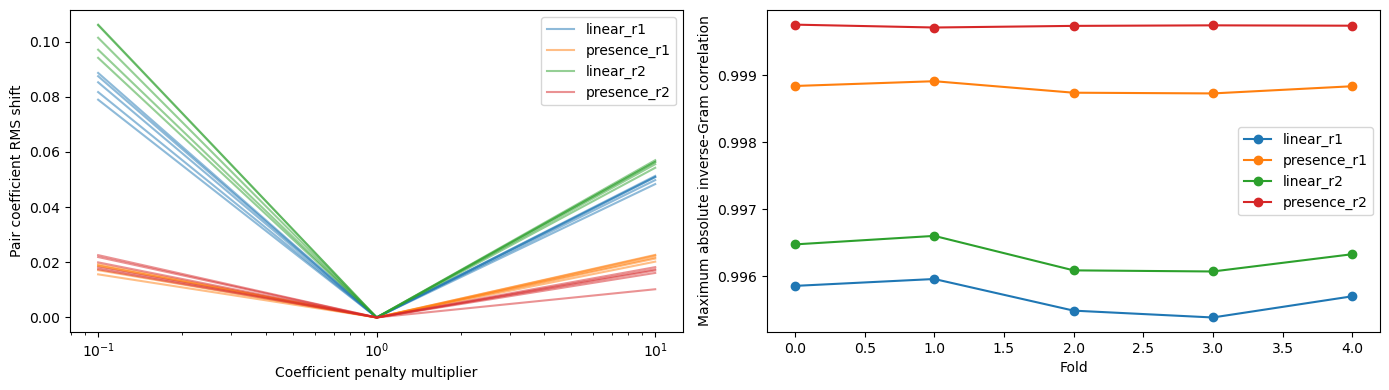

In [7]:
profile_rows=[];profile_parameters=[];ridge_rows=[];ridge_parameters=[];design_rows=[];correlation_rows=[]
sensitivity_responses=[]
for split in membership:
    fold=split['fold']
    inputs=load_bundle(run.directory/f'inputs/fold_{fold}_mean')
    train_samples=graph_samples(inputs['groups']['train'],2);val_samples=graph_samples(inputs['groups']['val'],2)
    for name in model_names:
        fitted=models[name,fold];m=copy.deepcopy(fitted);penalty=fit_info[name,fold]['best']['penalty']
        parameter_names=[f'a:{A}' for A in identity_names]+[f'beta:{A}<-{B}' for A in identity_names for b,B in enumerate(identity_names) if b!=m.reference_source]
        meta,replacement_design=replacement_designs[name]
        base_lambda=float(m.strength([1])[0]);base_theta=m.array(m.weights).copy();scale=float(m.target_scale)
        obj=TensorEnergyObjective(m,train_samples,device=DEVICE,solver_rtol=run.settings['solver_rtol'],**penalty)
        base_p=obj.pack();base_value,_=obj(base_p)
        if not np.allclose(base_theta,m.array(m.weights),rtol=1e-6,atol=1e-8):raise ValueError('Saved model does not solve its stated linear objective')
        base_theta=m.array(m.weights).copy()
        b=obj.batch;design=b.design(m);solver,_=b.solver(m,rtol=run.settings['solver_rtol'])
        x=solver(design);gram=(x.T@(b.weight[:,None]*x)).cpu().numpy()
        lengths=np.sqrt(np.maximum(np.diag(gram),1e-30));normalized=gram/np.outer(lengths,lengths)
        eig=np.linalg.eigvalsh(normalized);rank=int((eig>eig.max()*1e-10).sum())
        inv=np.linalg.pinv(gram,rcond=1e-10,hermitian=True);den=np.sqrt(np.maximum(np.diag(inv),1e-30));corr=inv/np.outer(den,den)
        offdiag=abs(corr-np.diag(np.diag(corr)))
        design_rows.append(dict(name=name,fold=fold,columns=len(gram),rank=rank,normalized_condition=eig.max()/eig.min() if eig.min()>0 else np.inf,
            max_abs_inverse_gram_correlation=offdiag.max() if rank==len(gram) else np.nan,pairs_above_09=int(np.triu(offdiag>.9,1).sum())))
        for i in range(len(gram)):
            for j in range(i+1,len(gram)):
                correlation_rows.append(dict(name=name,fold=fold,parameter_a=parameter_names[i],parameter_b=parameter_names[j],correlation=corr[i,j]))
        del design,solver,x,gram,inv
        base_val=float(energy_mse(fitted,val_samples,device=DEVICE).mean())
        for factor in PROFILE_FACTORS:
            strength=base_lambda*factor;p=np.array([np.log(np.expm1(strength))])
            value,gradient=obj(p);theta=m.array(m.weights).copy()
            mse_scaled=value-np.dot(obj.penalty*theta,theta)-obj.lambda_ridge*strength**2
            val_mse=float(energy_mse(m,val_samples,device=DEVICE).mean())
            profile_rows.append(dict(name=name,fold=fold,factor=factor,strength=strength,objective=value,base_objective=base_value,
                relative_objective_change=(value-base_value)/base_value,training_mse=mse_scaled*scale**2,validation_mse=val_mse,
                relative_validation_change=(val_mse-base_val)/base_val,center_shift_rms=np.sqrt(np.mean((theta[:t]-base_theta[:t])**2))*scale,
                pair_shift_rms=np.sqrt(np.mean((theta[t:]-base_theta[t:])**2))*scale))
            sensitivity_responses.extend(dict(name=name,fold=fold,kind='accommodation',factor=float(factor),eligible=(value-base_value)/base_value<=PROFILE_TOLERANCE,
                **row,response=float(v)) for row,v in zip(meta.to_dict('records'),replacement_design@(theta*scale)))
            profile_parameters.extend(dict(name=name,fold=fold,factor=factor,parameter=key,value=v*scale) for key,v in zip(parameter_names,theta))
        # Conditional penalty sensitivity: keep accommodation fixed and refit all linear coefficients.
        original_penalty=obj.penalty.copy()
        for factor in PENALTY_FACTORS:
            obj.penalty=original_penalty*factor;obj.tensor_penalty=b.tensor(obj.penalty)
            value,_=obj(base_p);theta=m.array(m.weights).copy()
            ridge_rows.append(dict(name=name,fold=fold,factor=factor,validation_mse=float(energy_mse(m,val_samples,device=DEVICE).mean()),
                center_shift_rms=np.sqrt(np.mean((theta[:t]-base_theta[:t])**2))*scale,
                pair_shift_rms=np.sqrt(np.mean((theta[t:]-base_theta[t:])**2))*scale))
            sensitivity_responses.extend(dict(name=name,fold=fold,kind='penalty',factor=float(factor),eligible=True,
                **row,response=float(v)) for row,v in zip(meta.to_dict('records'),replacement_design@(theta*scale)))
            ridge_parameters.extend(dict(name=name,fold=fold,factor=factor,parameter=key,value=v*scale) for key,v in zip(parameter_names,theta))
        print('Profiled',name,'fold',fold,'design rank',rank,'/',len(parameter_names),flush=True)
        del obj,b,m
        gc.collect()
        if DEVICE=='cuda':torch.cuda.empty_cache()
    del inputs,train_samples,val_samples
profiles=pd.DataFrame(profile_rows);profile_coefficients=pd.DataFrame(profile_parameters)
ridge_sensitivity=pd.DataFrame(ridge_rows);ridge_coefficients=pd.DataFrame(ridge_parameters)
design_diagnostics=pd.DataFrame(design_rows);parameter_correlations=pd.DataFrame(correlation_rows)
for filename,frame in [('accommodation_profiles',profiles),('profile_coefficients',profile_coefficients),('penalty_sensitivity',ridge_sensitivity),
                       ('penalty_coefficients',ridge_coefficients),('design_diagnostics',design_diagnostics),('conditional_correlations',parameter_correlations)]:
    frame.to_csv(OUTPUT_DIR/f'{filename}.csv',index=False)

sensitivity_responses=pd.DataFrame(sensitivity_responses);sensitivity_responses.to_csv(OUTPUT_DIR/'sensitivity_responses.csv',index=False)
profile_summary=profiles[profiles.relative_objective_change<=PROFILE_TOLERANCE].groupby(['name','fold']).agg(factor_low=('factor','min'),factor_high=('factor','max')).reset_index()
profile_summary.to_csv(OUTPUT_DIR/'profile_summary.csv',index=False)
robust=sensitivity_responses[sensitivity_responses.eligible].groupby(['name','hop','center','source']).response.agg(['min','max']).reset_index()
robust['robust_sign']=(robust['min']>RESPONSE_FLOOR)|(robust['max']<-RESPONSE_FLOOR)
robust.to_csv(OUTPUT_DIR/'response_robustness.csv',index=False)
fig,axes=plt.subplots(len(model_names),3,figsize=(15,3*len(model_names)),squeeze=False)
for row,name in enumerate(model_names):
    for fold,d in profiles[profiles.name==name].groupby('fold'):
        axes[row,0].plot(d.factor,100*d.relative_objective_change,alpha=.6)
        axes[row,1].plot(d.factor,d.center_shift_rms,color='tab:green',alpha=.5)
        axes[row,1].plot(d.factor,d.pair_shift_rms,color='tab:purple',alpha=.5)
        axes[row,2].plot(d.factor,100*d.relative_validation_change,alpha=.6)
    axes[row,0].axhline(100*PROFILE_TOLERANCE,color='0.4',ls=':');axes[row,0].set(title=name,ylabel='Penalized objective change (%)')
    axes[row,1].plot([],[],color='tab:green',label='Center');axes[row,1].plot([],[],color='tab:purple',label='Pair');axes[row,1].legend();axes[row,1].set(ylabel='Coefficient RMS shift')
    axes[row,2].set(ylabel='Validation MSE change (%)')
    for ax in axes[row]:ax.axvline(1,color='0.5',ls=':');ax.set(xscale='log',xlabel='Accommodation / fitted value')
fig.tight_layout();fig.savefig(OUTPUT_DIR/'accommodation_profiles.png',dpi=160);plt.show()
fig,axes=plt.subplots(1,2,figsize=(14,4))
for name in model_names:
    for fold,d in ridge_sensitivity[ridge_sensitivity.name==name].groupby('fold'):
        axes[0].plot(d.factor,d.pair_shift_rms,color=colors[name],alpha=.5,label=name if fold==membership[0]['fold'] else None)
    d=design_diagnostics[design_diagnostics.name==name];axes[1].plot(d.fold,d.max_abs_inverse_gram_correlation,'o-',color=colors[name],label=name)
axes[0].set(xscale='log',xlabel='Coefficient penalty multiplier',ylabel='Pair coefficient RMS shift');axes[0].legend()
axes[1].set(xlabel='Fold',ylabel='Maximum absolute inverse-Gram correlation');axes[1].legend()
fig.tight_layout();fig.savefig(OUTPUT_DIR/'identifiability_checks.png',dpi=160);plt.show()

## Report and reproducible handoff
Save the primary results and the diagnostic sensitivity conclusions. This report states explicitly what was changed and what remains an assumption. Quantities crossing the declared response floor are not counted as sign-robust. Do not infer activation preference for individual pairs from these global-family comparisons.

In [6]:
def markdown_table(frame):
    table=frame.reset_index()
    rows=['| '+' | '.join(map(str,table.columns))+' |','| '+' | '.join(['---']*len(table.columns))+' |']
    for values in table.itertuples(index=False,name=None):
        rows.append('| '+' | '.join(f'{v:.7g}' if isinstance(v,float) else str(v) for v in values)+' |')
    return '\n'.join(rows)

stats=stability[(stability.hop==1)&~stability.near_zero].groupby('name').agg(pairs=('source','size'),unanimous=('unanimous_sign','sum'),median_relative_dispersion=('relative_dispersion','median'))
stats.to_csv(OUTPUT_DIR/'stability_summary.csv')
lines=['# All-source fate interactions: linear versus literal presence','',
    f'Completed {len(models)} primary models on {len(membership)} exact saved folds; {total.organoid_str.nunique()} held-out organoids. All sources including Unassigned. Mean-curvature baseline/preprocessing copied exactly.','',
    '## Specification and changes','',
    'Direct fate radius 1 or 2; constant center preferences, pair amplitudes and shared accommodation. Linear activation is x; presence is 1[x>0], without learned threshold. Presence at two hops does not attenuate with distance once either ring contains the source. All-linear coefficients are contrasts relative to Unassigned, which is not assumed biologically inert. Presence fits all coefficients but its zero-source intercept may be extrapolated. No measured neighbor curvatures enter predictions.','',
    'The model implementation also accepts a fixed per-pair linear/presence map. No automatic pair selection was run: the agreed sequence tests the global families and compensation first.','',
    '## Accuracy (secondary)','',markdown_table(accuracy),'',
    '## Replacement stability','',markdown_table(stats),'',
    'Contrasts replace one existing hop-1 source with Unassigned and report intact minus replaced local preferred residual H, before accommodation. Organisms are equally weighted; all folds use the same fate-only reference contexts. Positive means retaining the source increases local preference relative to the replacement. Supported responses are not biological interventions. Presence can stay unchanged if another source cell remains, and adding Unassigned can also change the response.','',
    '## Accommodation and compensation','']
for name in model_names:
    a=accommodation[accommodation.name==name].strength;d=profile_summary[profile_summary.name==name]
    r=robust[(robust.name==name)&(robust.hop==1)]
    lines.append(f'- {name}: accommodation {a.mean():.4f} ± {a.std():.4f} fold SD; {int(((d.factor_low<=.5)|(d.factor_high>=2)).sum())}/5 folds allow a twofold or larger accommodation change within the 1% penalized-objective band. {int(r.robust_sign.sum())}/{len(r)} supported hop-1 contrasts retain a non-negligible sign across folds, competitive accommodation profiles and the tested penalty factors.')
lines+=['','Profiles refit local coefficients and are not confidence intervals. Penalty sensitivity holds accommodation fixed. Neither diagnostic establishes a unique physical decomposition. Conditional inverse-Gram correlations are design diagnostics, not biological correlations. Reference coding removes the exact all-linear composition ambiguity on populated rings; ridge still influences estimates.','',
    '## Figures','',
    '- `analysis/all_source_stability/accuracy_spatial.png`: total and adjacent-difference MSE.',
    '- `analysis/all_source_stability/regional_accuracy.png`: anatomical MSE.',
    '- `analysis/all_source_stability/novelty_accuracy.png`: error versus fate-context novelty; ordinary-fold diagnostic, not composition-blocked refitting.',
    '- `analysis/all_source_stability/replacement_heatmaps.png`: supported hop-1 replacement effects and unstable signs.',
    '- `analysis/all_source_stability/lgr5_and_accommodation.png`: LGR5 contrasts and fitted accommodation.',
    '- `analysis/all_source_stability/accommodation_profiles.png`: objective, coefficient and validation sensitivity.',
    '- `analysis/all_source_stability/identifiability_checks.png`: penalty sensitivity and conditional collinearity.',
    '- `analysis/all_source_stability/presence_support.png`: source-present fraction; presence/absence support is exported by fold.','',
    '## Limits and next decision','',
    'Training folds overlap. Baseline/preprocessing were fitted on outer training data, so inner selection is conditional on them. The composition novelty diagnostic does not establish extrapolation to deliberately withheld arrangements. Fixed response families and positive distance weights are assumptions. All-source, radius, and activation changes should not be interpreted as proof of any molecular pathway. Prefer response contrasts stable across folds and sensitivity settings; defer additional flexibility where those fail.']

lines+=['','## Main findings and interpretation','',
    '1. **Presence improves prediction, but the best MSE does not imply the best identification.** Two-hop presence has MSE 0.003869 versus 0.003980 for two-hop linear and 0.003776 for the saved FiLM reference. It also has the lowest adjacent-curvature-difference error among the new models. Direct radius 1 loses only modest accuracy, so it remains a useful simpler hypothesis.','',
    '2. **Fold consistency depends on the quantity examined.** Median relative fold disagreement of non-negligible hop-1 replacement means is about 15%/12% for linear radius 1/2 and 19%/38% for presence radius 1/2. Nevertheless, presence retains more non-negligible replacement signs over the tested penalty and accommodation perturbations (35/55 and 37/55, versus 27/55 and 24/55 for linear). These different diagnostics do not justify declaring either activation universally more interpretable. Denominators differ from the fold-only table because near-zero primary means are excluded there.','',
    '3. **Accommodation is still compensable.** Every fold of every variant allows at least a twofold change within the descriptive 1% penalized-objective band after refitting local coefficients. Fitted accommodation averages roughly 0.34–0.50 across specifications, versus about 0.14 in the earlier four-source model; source expansion and reference/regularization conventions changed together, so this is not attributable to one cause. A reproducible optimum is not a material constant.','',
    '4. **All-source models have strongly correlated coefficients despite full conditional design rank.** The strongest inverse-Gram correlations are about 0.995–0.997 for linear, 0.999 for one-hop presence and 0.9997 for two-hop presence. A leading example is the AldoB center preference versus AldoB-neighbor presence. AldoB is present around AldoB centers in roughly 94% of one-hop and 97% of two-hop organoid-weighted sampled training contexts. This makes the indicator close to a center-specific intercept; these percentages describe the fate-only diagnostic sample.','',
    '5. **Some LGR5 contrasts are robust, while the Lysozyme conclusion depends on response construction.** Retaining Chroma or Serotonin instead of Unassigned gives a positive local-preference contrast in every model and across the declared sensitivity tests. Lysozyme is positive across folds for linear and one-hop presence, but two-hop presence crosses zero across folds, and both presence variants lose sign robustness under the sensitivity tests. Removing one hop-1 Lysozyme removes the final Lysozyme source in about 82% of eligible sampled contexts at radius 1, but only 39% at radius 2 (cell-weighted diagnostic fractions). This helps explain why a presence-based one-cell replacement can become weak at radius 2; it does not prove the underlying fitted source amplitude is zero.','',
    '6. **Spatial variation remains underpredicted.** Predicted adjacent-difference energy is roughly 11–14% of measured energy, despite improved edge-difference MSE. Measurement noise, incomplete fate information and accommodation can all contribute; this diagnostic cannot attribute the discrepancy to mechanics alone. Novel fate-composition contexts have higher errors for all variants, without establishing a causal or deliberately blocked extrapolation test.','',
    '## Recommended next step','',
    'Retain one- and two-hop linear/presence models as sensitivity references. Interpret supported replacements rather than absolute cell preferences or pair amplitudes. Do not add learned per-pair activation selection merely because presence improves MSE: composition collinearity and accommodation compensation remain substantial. The fixed per-pair option is implemented for prespecified hypotheses, but data-driven selection should wait for a clear validation criterion and adequate presence/absence support. A common fixed-accommodation sensitivity grid or an independently motivated calibration is preferable to claiming that the current fits identify mechanical strength.']

(run.directory/'REPORT.md').write_text('\n'.join(lines)+'\n')
(OUTPUT_DIR/'complete.json').write_text(json.dumps(dict(models=len(models),organoids=total.organoid_str.nunique(),profiles=len(profiles),prediction_audit=max_difference),indent=2))
display(Markdown((run.directory/'REPORT.md').read_text()))

# All-source fate interactions: linear versus literal presence

Completed 20 primary models on 5 exact saved folds; 1170 held-out organoids. All sources including Unassigned. Mean-curvature baseline/preprocessing copied exactly.

## Specification and changes

Direct fate radius 1 or 2; constant center preferences, pair amplitudes and shared accommodation. Linear activation is x; presence is 1[x>0], without learned threshold. Presence at two hops does not attenuate with distance once either ring contains the source. All-linear coefficients are contrasts relative to Unassigned, which is not assumed biologically inert. Presence fits all coefficients but its zero-source intercept may be extrapolated. No measured neighbor curvatures enter predictions.

The model implementation also accepts a fixed per-pair linear/presence map. No automatic pair selection was run: the agreed sequence tests the global families and compensation first.

## Accuracy (secondary)

| name | mean | sem | count |
| --- | --- | --- | --- |
| Baseline | 0.004603845 | 8.358618e-05 | 1170 |
| FiLM | 0.003776364 | 6.864264e-05 | 1170 |
| linear_r1 | 0.004029674 | 7.11655e-05 | 1170 |
| linear_r2 | 0.00398045 | 7.051107e-05 | 1170 |
| presence_r1 | 0.003953356 | 6.95951e-05 | 1170 |
| presence_r2 | 0.003869066 | 6.85339e-05 | 1170 |
| previous_four_source_linear | 0.004087207 | 7.258173e-05 | 1170 |

## Replacement stability

| name | pairs | unanimous | median_relative_dispersion |
| --- | --- | --- | --- |
| linear_r1 | 53 | 47 | 0.1483452 |
| linear_r2 | 54 | 51 | 0.124797 |
| presence_r1 | 55 | 51 | 0.1914506 |
| presence_r2 | 55 | 48 | 0.3831665 |

Contrasts replace one existing hop-1 source with Unassigned and report intact minus replaced local preferred residual H, before accommodation. Organisms are equally weighted; all folds use the same fate-only reference contexts. Positive means retaining the source increases local preference relative to the replacement. Supported responses are not biological interventions. Presence can stay unchanged if another source cell remains, and adding Unassigned can also change the response.

## Accommodation and compensation

- linear_r1: accommodation 0.3410 ± 0.0119 fold SD; 5/5 folds allow a twofold or larger accommodation change within the 1% penalized-objective band. 27/55 supported hop-1 contrasts retain a non-negligible sign across folds, competitive accommodation profiles and the tested penalty factors.
- presence_r1: accommodation 0.5006 ± 0.0102 fold SD; 5/5 folds allow a twofold or larger accommodation change within the 1% penalized-objective band. 35/55 supported hop-1 contrasts retain a non-negligible sign across folds, competitive accommodation profiles and the tested penalty factors.
- linear_r2: accommodation 0.4927 ± 0.0192 fold SD; 5/5 folds allow a twofold or larger accommodation change within the 1% penalized-objective band. 24/55 supported hop-1 contrasts retain a non-negligible sign across folds, competitive accommodation profiles and the tested penalty factors.
- presence_r2: accommodation 0.4387 ± 0.0389 fold SD; 5/5 folds allow a twofold or larger accommodation change within the 1% penalized-objective band. 37/55 supported hop-1 contrasts retain a non-negligible sign across folds, competitive accommodation profiles and the tested penalty factors.

Profiles refit local coefficients and are not confidence intervals. Penalty sensitivity holds accommodation fixed. Neither diagnostic establishes a unique physical decomposition. Conditional inverse-Gram correlations are design diagnostics, not biological correlations. Reference coding removes the exact all-linear composition ambiguity on populated rings; ridge still influences estimates.

## Figures

- `analysis/all_source_stability/accuracy_spatial.png`: total and adjacent-difference MSE.
- `analysis/all_source_stability/regional_accuracy.png`: anatomical MSE.
- `analysis/all_source_stability/novelty_accuracy.png`: error versus fate-context novelty; ordinary-fold diagnostic, not composition-blocked refitting.
- `analysis/all_source_stability/replacement_heatmaps.png`: supported hop-1 replacement effects and unstable signs.
- `analysis/all_source_stability/lgr5_and_accommodation.png`: LGR5 contrasts and fitted accommodation.
- `analysis/all_source_stability/accommodation_profiles.png`: objective, coefficient and validation sensitivity.
- `analysis/all_source_stability/identifiability_checks.png`: penalty sensitivity and conditional collinearity.
- `analysis/all_source_stability/presence_support.png`: source-present fraction; presence/absence support is exported by fold.

## Limits and next decision

Training folds overlap. Baseline/preprocessing were fitted on outer training data, so inner selection is conditional on them. The composition novelty diagnostic does not establish extrapolation to deliberately withheld arrangements. Fixed response families and positive distance weights are assumptions. All-source, radius, and activation changes should not be interpreted as proof of any molecular pathway. Prefer response contrasts stable across folds and sensitivity settings; defer additional flexibility where those fail.

## Main findings and interpretation

1. **Presence improves prediction, but the best MSE does not imply the best identification.** Two-hop presence has MSE 0.003869 versus 0.003980 for two-hop linear and 0.003776 for the saved FiLM reference. It also has the lowest adjacent-curvature-difference error among the new models. Direct radius 1 loses only modest accuracy, so it remains a useful simpler hypothesis.

2. **Fold consistency depends on the quantity examined.** Median relative fold disagreement of non-negligible hop-1 replacement means is about 15%/12% for linear radius 1/2 and 19%/38% for presence radius 1/2. Nevertheless, presence retains more non-negligible replacement signs over the tested penalty and accommodation perturbations (35/55 and 37/55, versus 27/55 and 24/55 for linear). These different diagnostics do not justify declaring either activation universally more interpretable. Denominators differ from the fold-only table because near-zero primary means are excluded there.

3. **Accommodation is still compensable.** Every fold of every variant allows at least a twofold change within the descriptive 1% penalized-objective band after refitting local coefficients. Fitted accommodation averages roughly 0.34–0.50 across specifications, versus about 0.14 in the earlier four-source model; source expansion and reference/regularization conventions changed together, so this is not attributable to one cause. A reproducible optimum is not a material constant.

4. **All-source models have strongly correlated coefficients despite full conditional design rank.** The strongest inverse-Gram correlations are about 0.995–0.997 for linear, 0.999 for one-hop presence and 0.9997 for two-hop presence. A leading example is the AldoB center preference versus AldoB-neighbor presence. AldoB is present around AldoB centers in roughly 94% of one-hop and 97% of two-hop organoid-weighted sampled training contexts. This makes the indicator close to a center-specific intercept; these percentages describe the fate-only diagnostic sample.

5. **Some LGR5 contrasts are robust, while the Lysozyme conclusion depends on response construction.** Retaining Chroma or Serotonin instead of Unassigned gives a positive local-preference contrast in every model and across the declared sensitivity tests. Lysozyme is positive across folds for linear and one-hop presence, but two-hop presence crosses zero across folds, and both presence variants lose sign robustness under the sensitivity tests. Removing one hop-1 Lysozyme removes the final Lysozyme source in about 82% of eligible sampled contexts at radius 1, but only 39% at radius 2 (cell-weighted diagnostic fractions). This helps explain why a presence-based one-cell replacement can become weak at radius 2; it does not prove the underlying fitted source amplitude is zero.

6. **Spatial variation remains underpredicted.** Predicted adjacent-difference energy is roughly 11–14% of measured energy, despite improved edge-difference MSE. Measurement noise, incomplete fate information and accommodation can all contribute; this diagnostic cannot attribute the discrepancy to mechanics alone. Novel fate-composition contexts have higher errors for all variants, without establishing a causal or deliberately blocked extrapolation test.

## Recommended next step

Retain one- and two-hop linear/presence models as sensitivity references. Interpret supported replacements rather than absolute cell preferences or pair amplitudes. Do not add learned per-pair activation selection merely because presence improves MSE: composition collinearity and accommodation compensation remain substantial. The fixed per-pair option is implemented for prespecified hypotheses, but data-driven selection should wait for a clear validation criterion and adequate presence/absence support. A common fixed-accommodation sensitivity grid or an independently motivated calibration is preferable to claiming that the current fits identify mechanical strength.
